# AI Learning Usage Analysis

This version includes:
- data preprocessing
- outlier detection
- basic visualizations
- corrected VIF function
- improved heatmap logic
- behavior-focused models
- controlled models
- Lasso regression
- L1-regularized logistic regression


In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "ai_impact_student_performance_dataset.csv"
SEED = 42

display(Markdown("### Data path"))
print(DATA_PATH)


### Data path

ai_impact_student_performance_dataset.csv


In [12]:
raw_df = pd.read_csv(DATA_PATH)

display(Markdown("### Raw data preview"))
display(raw_df.head())

display(Markdown("### Raw data shape"))
display(pd.DataFrame({"rows":[raw_df.shape[0]], "columns":[raw_df.shape[1]]}))

display(Markdown("### Raw column types"))
display(pd.DataFrame({
    "column": raw_df.columns,
    "dtype": [str(x) for x in raw_df.dtypes]
}))


### Raw data preview

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


### Raw data shape

,rows,columns
0,8000,26


### Raw column types

,column,dtype
0,student_id,int64
1,age,int64
2,gender,object
3,grade_level,object
4,study_hours_per_day,float64
5,uses_ai,int64
6,ai_usage_time_minutes,int64
7,ai_tools_used,object
8,ai_usage_purpose,object
9,ai_dependency_score,int64


## 1. Data preprocessing

In [13]:
df = raw_df.copy()

missing_df = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values
}).sort_values(["missing_pct", "missing_count"], ascending=False)

duplicate_count = df.duplicated().sum()

display(Markdown("### Missing value summary"))
display(missing_df)

display(Markdown("### Duplicate rows"))
display(pd.DataFrame({"duplicate_rows":[duplicate_count]}))

if duplicate_count > 0:
    df = df.drop_duplicates().copy()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

if "uses_ai" in df.columns:
    if df["uses_ai"].dtype == "object":
        df["uses_ai_binary"] = df["uses_ai"].astype(str).str.lower().isin(["yes", "1", "true"]).astype(int)
    else:
        df["uses_ai_binary"] = df["uses_ai"].astype(int)
else:
    df["uses_ai_binary"] = np.where(df.get("ai_usage_time_minutes", 0).fillna(0) > 0, 1, 0)

if "at_risk" not in df.columns:
    df["at_risk"] = (df["final_score"] < 50).astype(int)

if "ai_dependency_score" in df.columns:
    df["ai_dependency_group"] = pd.cut(
        df["ai_dependency_score"], bins=[0, 3, 7, 10],
        labels=["Low", "Medium", "High"], include_lowest=True
    )

if "ai_generated_content_percentage" in df.columns:
    df["ai_generation_group_fixed"] = pd.cut(
        df["ai_generated_content_percentage"], bins=[-0.1, 30, 70, 100],
        labels=["Low", "Medium", "High"], include_lowest=True
    )

ai_subset = df[df["uses_ai_binary"] == 1].copy()

if "ai_generated_content_percentage" in ai_subset.columns and ai_subset["ai_generated_content_percentage"].notna().sum() >= 3:
    try:
        ai_subset["ai_generation_group_q"] = pd.qcut(
            ai_subset["ai_generated_content_percentage"], q=3,
            labels=["Low", "Medium", "High"], duplicates="drop"
        )
    except Exception:
        ai_subset["ai_generation_group_q"] = ai_subset["ai_generation_group_fixed"]

def derive_ai_usage_style(row):
    purpose = str(row.get("ai_usage_purpose", "Unknown"))
    gen = row.get("ai_generated_content_percentage", np.nan)
    dep = row.get("ai_dependency_score", np.nan)
    supportive_purposes = {"Exam Prep", "Doubt Solving", "Coding"}
    substitutive_purposes = {"Homework", "Notes"}
    if pd.notna(gen) and pd.notna(dep):
        if (purpose in supportive_purposes) and (gen <= 30) and (dep <= 7):
            return "Supportive"
        if (gen > 70) or ((purpose in substitutive_purposes) and (dep >= 8)):
            return "Substitutive"
    return "Mixed"

if len(ai_subset) > 0:
    ai_subset["ai_usage_style"] = ai_subset.apply(derive_ai_usage_style, axis=1)

display(Markdown("### Preprocessed full sample preview"))
display(df.head())
display(Markdown("### Preprocessed AI subset preview"))
display(ai_subset.head())


### Missing value summary

,column,missing_count,missing_pct
7,ai_tools_used,1362,17.03
8,ai_usage_purpose,1346,16.83
0,student_id,0,0.00
1,age,0,0.00
2,gender,0,0.00
3,grade_level,0,0.00
4,study_hours_per_day,0,0.00
5,uses_ai,0,0.00
6,ai_usage_time_minutes,0,0.00
9,ai_dependency_score,0,0.00


### Duplicate rows

,duplicate_rows
0,0


### Preprocessed full sample preview

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category,uses_ai_binary,at_risk,ai_dependency_group,ai_generation_group_fixed
0,1,20,Female,1st Year,2.5,1,170,nan,Exam Prep,10,...,1.5,4.6,6,36.8,0,Low,1,1,High,Low
1,2,17,Male,12th,3.4,1,123,nan,Notes,4,...,5.1,2.7,6,65.5,1,Medium,1,0,Medium,Low
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,0.2,4.0,3,66.3,1,Medium,0,0,High,High
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,4.2,2.9,2,69.5,1,Medium,0,0,Low,High
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,0.2,2.9,2,49.7,1,Low,1,1,Low,High


### Preprocessed AI subset preview

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,class_participation_score,final_score,passed,performance_category,uses_ai_binary,at_risk,ai_dependency_group,ai_generation_group_fixed,ai_generation_group_q,ai_usage_style
0,1,20,Female,1st Year,2.5,1,170,nan,Exam Prep,10,...,6,36.8,0,Low,1,1,High,Low,Low,Mixed
1,2,17,Male,12th,3.4,1,123,nan,Notes,4,...,6,65.5,1,Medium,1,0,Medium,Low,Low,Mixed
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,2,49.7,1,Low,1,1,Low,High,High,Substitutive
5,6,20,Male,1st Year,5.1,1,34,Copilot,Coding,10,...,4,77.9,1,High,1,0,High,Low,Low,Mixed
6,7,23,Female,1st Year,2.0,1,112,ChatGPT+Gemini,nan,8,...,5,82.2,1,High,1,0,High,Medium,Medium,Mixed


## 2. Outlier detection / 异常值检测

In [14]:
continuous_candidates = [
    "final_score", "ai_generated_content_percentage", "ai_dependency_score",
    "ai_prompts_per_week", "ai_usage_time_minutes", "study_hours_per_day",
    "study_consistency_index", "attendance_percentage", "class_participation_score",
    "sleep_hours", "social_media_hours", "tutoring_hours",
    "last_exam_score", "assignment_scores_avg", "concept_understanding_score"
]
continuous_cols = [c for c in continuous_candidates if c in df.columns]

def iqr_outlier_summary(dataframe, cols):
    rows = []
    for col in cols:
        s = dataframe[col].dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        rows.append({
            "variable": col,
            "Q1": round(q1, 3),
            "Q3": round(q3, 3),
            "IQR": round(iqr, 3),
            "lower_bound": round(lower, 3),
            "upper_bound": round(upper, 3),
            "outlier_count": int(outlier_mask.sum()),
            "outlier_pct": round(outlier_mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

display(Markdown("### IQR outlier summary — full sample"))
display(iqr_outlier_summary(df, continuous_cols))


### IQR outlier summary — full sample

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,final_score,47.30,66.2,18.90,18.950,94.550,6,0.08
1,ai_generated_content_percentage,25.00,76.0,51.00,-51.500,152.500,0,0.00
2,ai_dependency_score,3.00,8.0,5.00,-4.500,15.500,0,0.00
3,ai_prompts_per_week,29.00,90.0,61.00,-62.500,181.500,0,0.00
4,ai_usage_time_minutes,43.00,134.0,91.00,-93.500,270.500,0,0.00
5,study_hours_per_day,1.90,4.6,2.70,-2.150,8.650,0,0.00
6,study_consistency_index,3.20,7.8,4.60,-3.700,14.700,0,0.00
7,attendance_percentage,54.80,84.6,29.80,10.100,129.300,0,0.00
8,class_participation_score,3.00,8.0,5.00,-4.500,15.500,0,0.00
9,sleep_hours,5.20,7.7,2.50,1.450,11.450,0,0.00


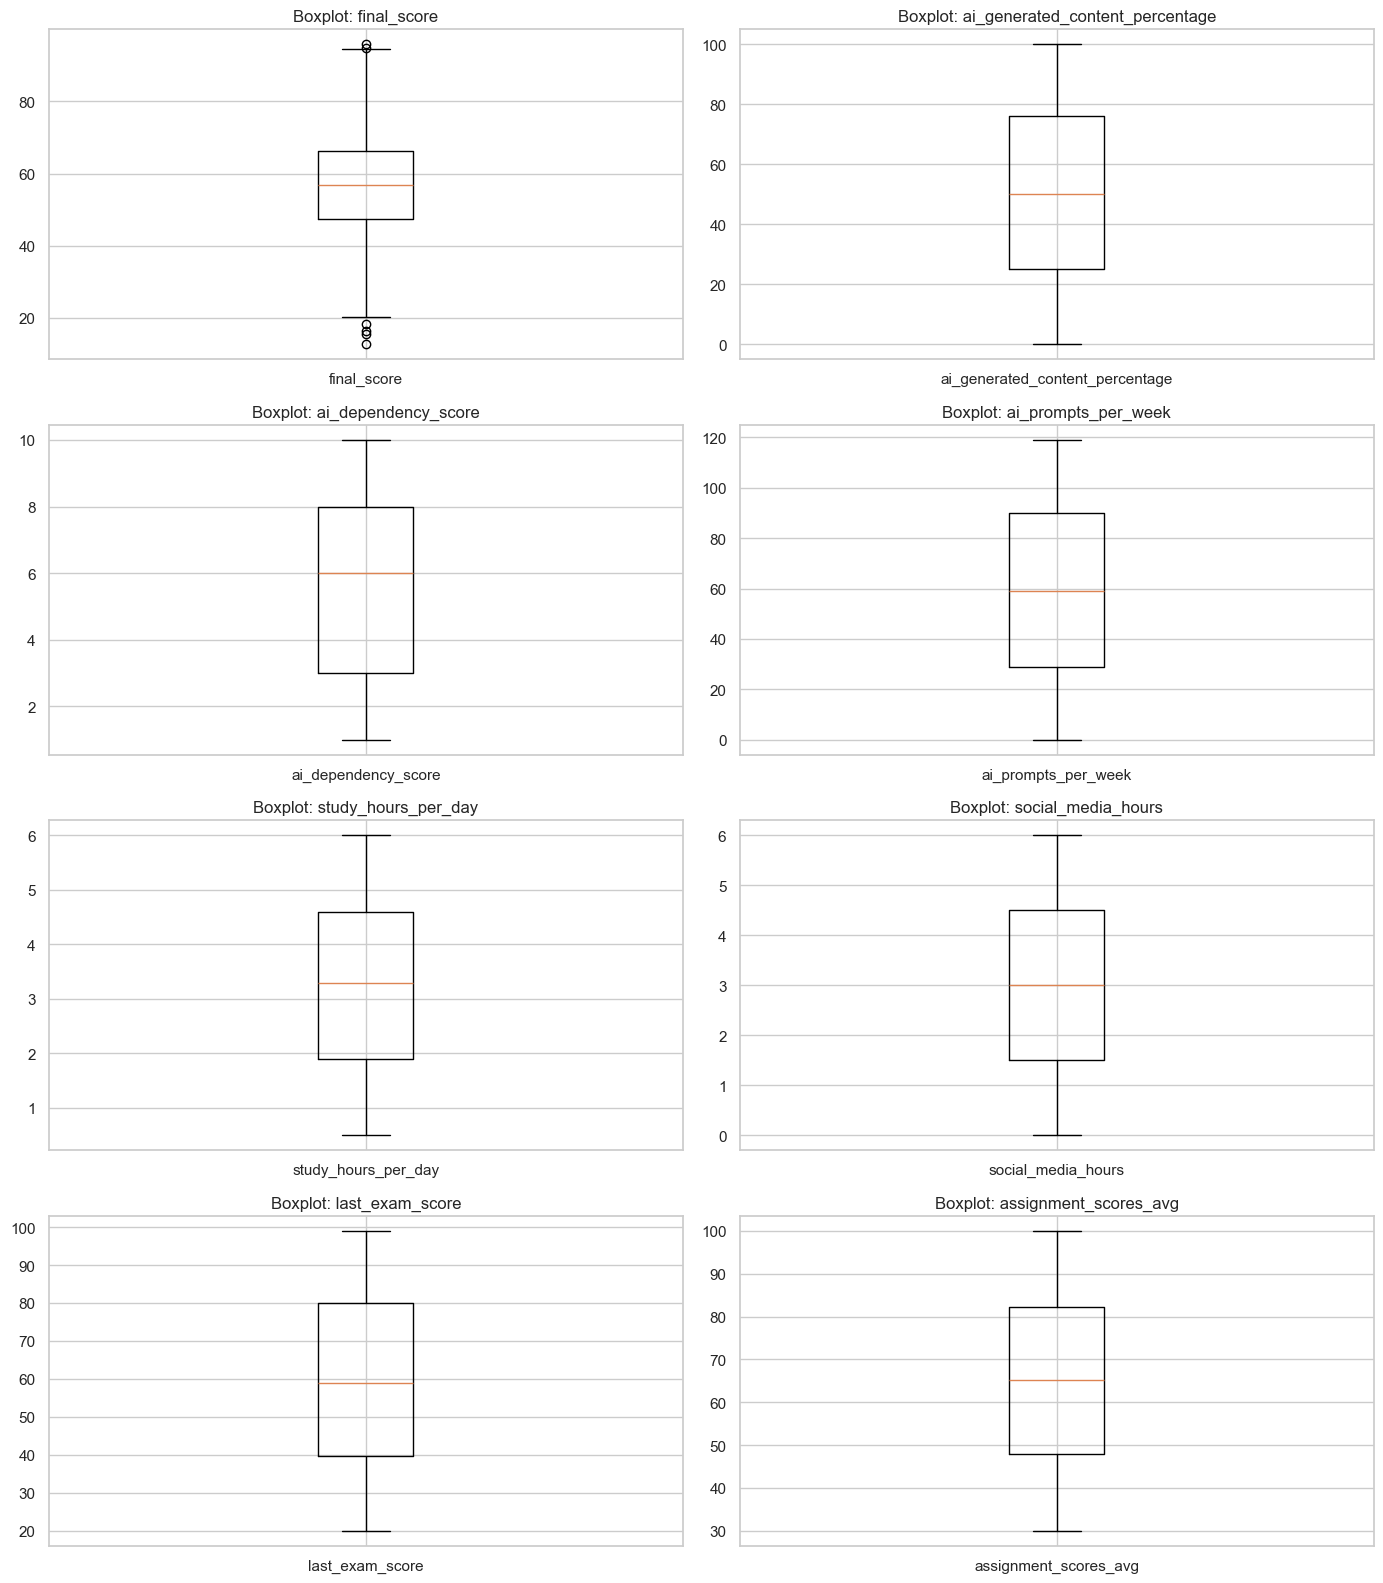

In [15]:
box_cols = [c for c in [
    "final_score", "ai_generated_content_percentage", "ai_dependency_score",
    "ai_prompts_per_week", "study_hours_per_day", "social_media_hours",
    "last_exam_score", "assignment_scores_avg"
] if c in df.columns]

n = len(box_cols); ncols = 2; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, box_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f"Boxplot: {col}")
    ax.set_xticklabels([col])

for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Basic visualizations

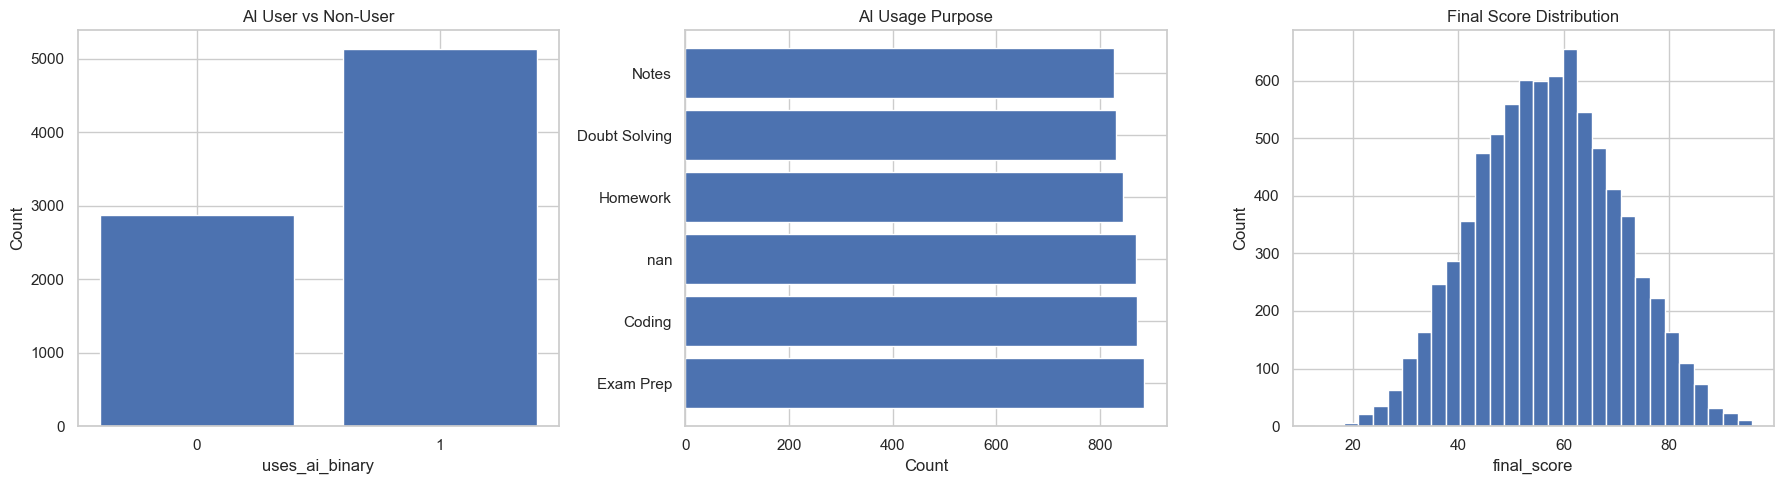

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vc = df["uses_ai_binary"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values)
axes[0].set_title("AI User vs Non-User")
axes[0].set_xlabel("uses_ai_binary"); axes[0].set_ylabel("Count")

if "ai_usage_purpose" in ai_subset.columns:
    purpose_counts = ai_subset["ai_usage_purpose"].value_counts()
    axes[1].barh(purpose_counts.index.astype(str), purpose_counts.values)
    axes[1].set_title("AI Usage Purpose")
    axes[1].set_xlabel("Count")

axes[2].hist(df["final_score"].dropna(), bins=30)
axes[2].set_title("Final Score Distribution")
axes[2].set_xlabel("final_score"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


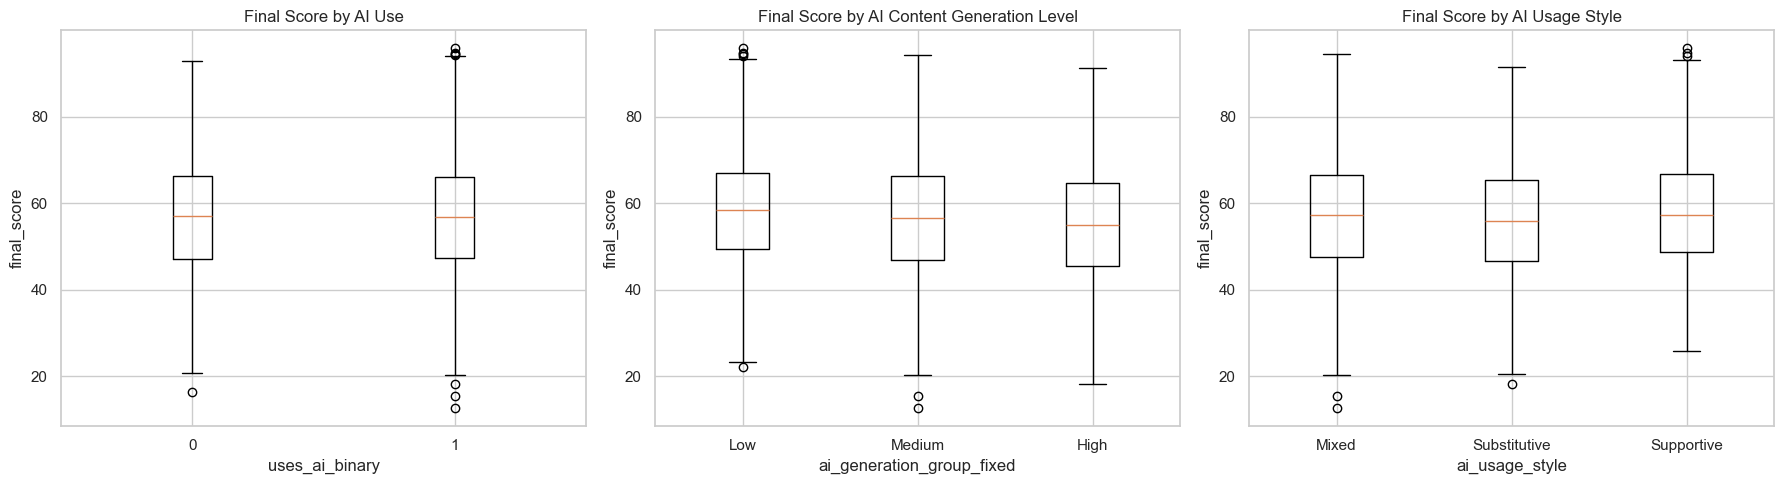

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

groups = [df.loc[df["uses_ai_binary"] == g, "final_score"].dropna().values for g in sorted(df["uses_ai_binary"].dropna().unique())]
axes[0].boxplot(groups, tick_labels=[str(g) for g in sorted(df["uses_ai_binary"].dropna().unique())])
axes[0].set_title("Final Score by AI Use")
axes[0].set_xlabel("uses_ai_binary"); axes[0].set_ylabel("final_score")

if "ai_generation_group_fixed" in ai_subset.columns:
    order = ["Low", "Medium", "High"]
    groups2 = [ai_subset.loc[ai_subset["ai_generation_group_fixed"].astype(str) == g, "final_score"].dropna().values for g in order]
    axes[1].boxplot(groups2, tick_labels=order)
    axes[1].set_title("Final Score by AI Content Generation Level")
    axes[1].set_xlabel("ai_generation_group_fixed"); axes[1].set_ylabel("final_score")

if "ai_usage_style" in ai_subset.columns:
    order3 = ["Mixed", "Substitutive", "Supportive"]
    groups3 = [ai_subset.loc[ai_subset["ai_usage_style"] == g, "final_score"].dropna().values for g in order3]
    axes[2].boxplot(groups3, tick_labels=order3)
    axes[2].set_title("Final Score by AI Usage Style")
    axes[2].set_xlabel("ai_usage_style"); axes[2].set_ylabel("final_score")

plt.tight_layout()
plt.show()


## 4. Heatmaps

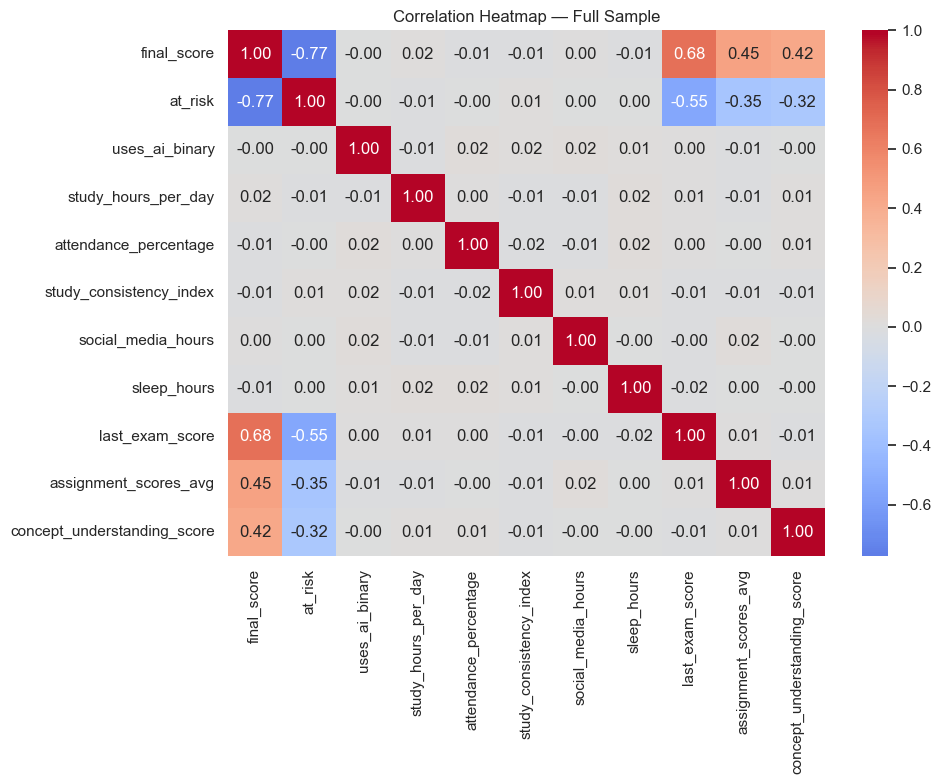

In [18]:
heat_cols_full = [c for c in [
    "final_score", "at_risk", "uses_ai_binary",
    "study_hours_per_day", "attendance_percentage", "study_consistency_index",
    "social_media_hours", "sleep_hours",
    "last_exam_score", "assignment_scores_avg", "concept_understanding_score"
] if c in df.columns]

corr_full = df[heat_cols_full].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Full Sample")
plt.tight_layout()
plt.show()


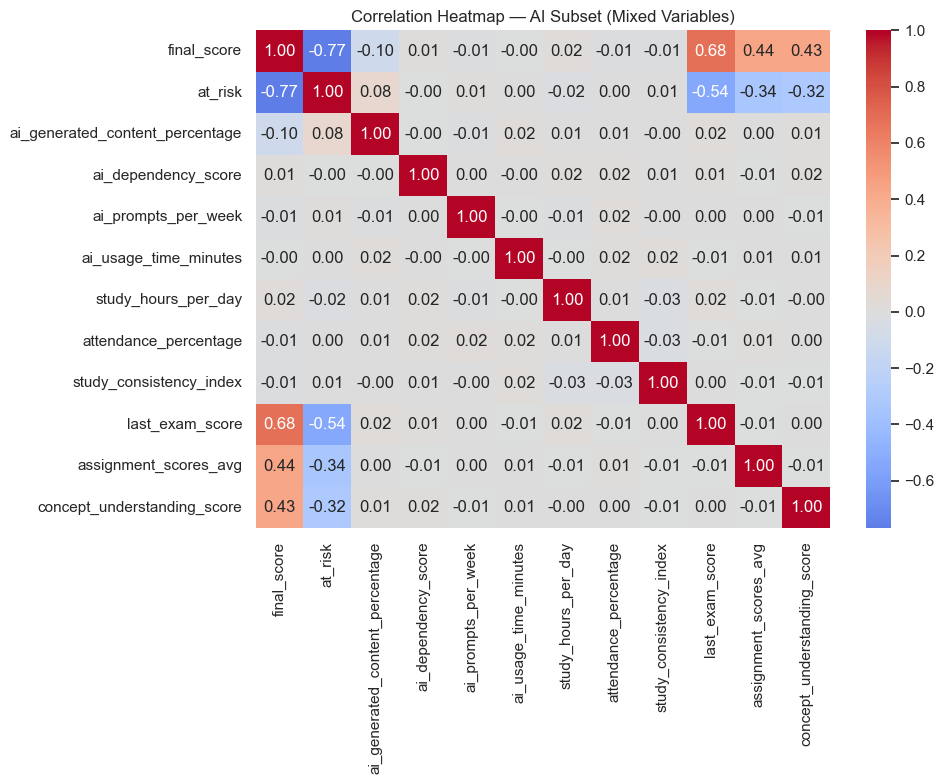

In [19]:
heat_cols_ai_mixed = [c for c in [
    "final_score", "at_risk",
    "ai_generated_content_percentage", "ai_dependency_score",
    "ai_prompts_per_week", "ai_usage_time_minutes",
    "study_hours_per_day", "attendance_percentage", "study_consistency_index",
    "last_exam_score", "assignment_scores_avg", "concept_understanding_score"
] if c in ai_subset.columns]

corr_ai_mixed = ai_subset[heat_cols_ai_mixed].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_ai_mixed, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — AI Subset (Mixed Variables)")
plt.tight_layout()
plt.show()


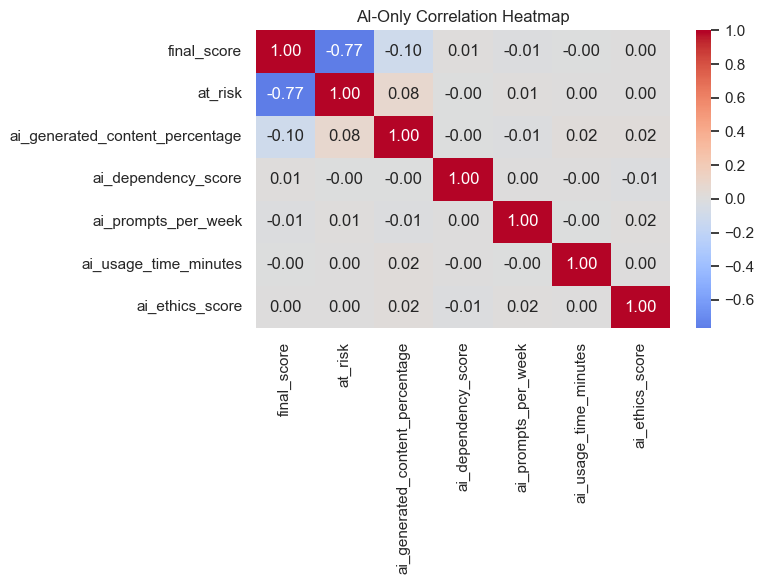

In [20]:
heat_cols_ai_only = [c for c in [
    "final_score", "at_risk",
    "ai_generated_content_percentage", "ai_dependency_score",
    "ai_prompts_per_week", "ai_usage_time_minutes",
    "ai_ethics_score"
] if c in ai_subset.columns]

corr_ai_only = ai_subset[heat_cols_ai_only].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_ai_only, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("AI-Only Correlation Heatmap")
plt.tight_layout()
plt.show()


### Full-sample target correlations

,final_score,at_risk
uses_ai_binary,-0.002,-0.004
study_hours_per_day,0.016,-0.013
attendance_percentage,-0.005,-0.000
study_consistency_index,-0.014,0.014
social_media_hours,0.004,0.003
sleep_hours,-0.006,0.002
last_exam_score,0.682,-0.545
assignment_scores_avg,0.455,-0.346
concept_understanding_score,0.424,-0.318


### AI-subset target correlations (mixed variables)

,final_score,at_risk
ai_generated_content_percentage,-0.103,0.082
ai_dependency_score,0.012,-0.005
ai_prompts_per_week,-0.011,0.015
ai_usage_time_minutes,-0.004,0.005
study_hours_per_day,0.020,-0.022
attendance_percentage,-0.013,0.005
study_consistency_index,-0.011,0.006
last_exam_score,0.681,-0.540
assignment_scores_avg,0.443,-0.337
concept_understanding_score,0.430,-0.318


### AI-only target correlations

,final_score,at_risk
ai_generated_content_percentage,-0.103,0.082
ai_dependency_score,0.012,-0.005
ai_prompts_per_week,-0.011,0.015
ai_usage_time_minutes,-0.004,0.005
ai_ethics_score,0.004,0.002


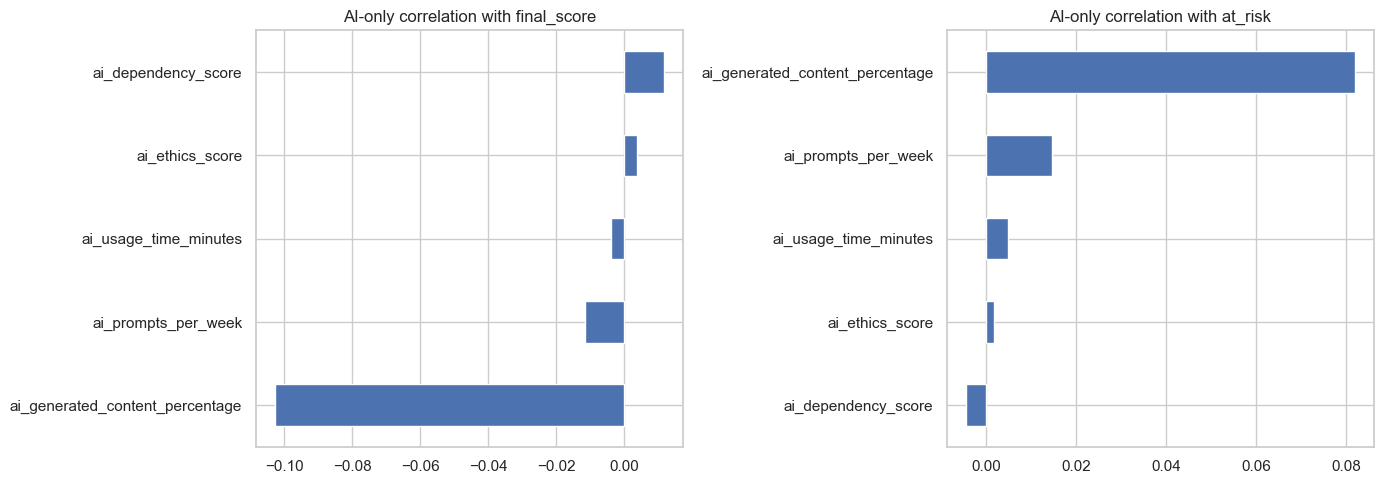

In [21]:
corr_target_full = corr_full[["final_score", "at_risk"]].drop(index=["final_score", "at_risk"], errors="ignore").copy()
corr_target_ai_mixed = corr_ai_mixed[["final_score", "at_risk"]].drop(index=["final_score", "at_risk"], errors="ignore").copy()
corr_target_ai_only = corr_ai_only[["final_score", "at_risk"]].drop(index=["final_score", "at_risk"], errors="ignore").copy()

display(Markdown("### Full-sample target correlations"))
display(corr_target_full.round(3))
display(Markdown("### AI-subset target correlations (mixed variables)"))
display(corr_target_ai_mixed.round(3))
display(Markdown("### AI-only target correlations"))
display(corr_target_ai_only.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr_target_ai_only["final_score"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("AI-only correlation with final_score")
corr_target_ai_only["at_risk"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("AI-only correlation with at_risk")
plt.tight_layout()
plt.show()


### Interactive Heatmaps

In [22]:
# Interaction Heatmap 1: Mean Final Score
if "ai_usage_purpose" in ai_subset.columns and "ai_generation_group_fixed" in ai_subset.columns:
    # Create pivot table for mean final scores
    interact_mean = ai_subset.pivot_table(
        values="final_score",
        index="ai_usage_purpose",
        columns="ai_generation_group_fixed",
        aggfunc="mean"
    )
    
    # Reorder columns
    desired_cols = ["Low", "Medium", "High"]
    interact_mean = interact_mean[[c for c in desired_cols if c in interact_mean.columns]]
    
    # Create interactive heatmap
    fig1 = go.Figure(data=go.Heatmap(
        z=interact_mean.values,
        x=interact_mean.columns,
        y=interact_mean.index,
        text=interact_mean.values.round(2),
        texttemplate='%{text:.2f}',
        textfont={"size": 12},
        colorscale="Blues",
        hovertemplate='Purpose: %{y}<br>AI Generation: %{x}<br>Mean Score: %{z:.2f}<extra></extra>'
    ))
    
    fig1.update_layout(
        title="Interaction Heatmap: Mean Final Score",
        xaxis_title="ai_generation_group_fixed",
        yaxis_title="ai_usage_purpose",
        width=700,
        height=500
    )
    
    fig1.show()
    display(Markdown("*This interactive heatmap shows the mean final score across different AI usage purposes and AI content generation levels.*"))

*This interactive heatmap shows the mean final score across different AI usage purposes and AI content generation levels.*

In [23]:
# Interaction Heatmap 2: At-Risk Rate
if "ai_usage_purpose" in ai_subset.columns and "ai_generation_group_fixed" in ai_subset.columns and "at_risk" in ai_subset.columns:
    # Create pivot table for at-risk rates
    interact_risk = ai_subset.pivot_table(
        values="at_risk",
        index="ai_usage_purpose",
        columns="ai_generation_group_fixed",
        aggfunc="mean"
    )
    
    # Reorder columns
    desired_cols = ["Low", "Medium", "High"]
    interact_risk = interact_risk[[c for c in desired_cols if c in interact_risk.columns]]
    
    # Create interactive heatmap
    fig2 = go.Figure(data=go.Heatmap(
        z=interact_risk.values,
        x=interact_risk.columns,
        y=interact_risk.index,
        text=(interact_risk.values * 100).round(1),
        texttemplate='%{text:.1f}%',
        textfont={"size": 12},
        colorscale="Reds",
        hovertemplate='Purpose: %{y}<br>AI Generation: %{x}<br>At-Risk Rate: %{z:.1%}<extra></extra>'
    ))
    
    fig2.update_layout(
        title="Interaction Heatmap: At-Risk Rate",
        xaxis_title="ai_generation_group_fixed",
        yaxis_title="ai_usage_purpose",
        width=700,
        height=500
    )
    
    fig2.show()
    display(Markdown("*This interactive heatmap shows the proportion of at-risk students (final_score < 50) across different AI usage purposes and AI content generation levels.*"))

*This interactive heatmap shows the proportion of at-risk students (final_score < 50) across different AI usage purposes and AI content generation levels.*

## 5. Modeling setup

In [24]:
behavior_numeric = [
    "ai_generated_content_percentage", "ai_dependency_score",
    "ai_prompts_per_week", "ai_usage_time_minutes",
    "study_hours_per_day", "study_consistency_index",
    "attendance_percentage", "class_participation_score",
    "sleep_hours", "social_media_hours", "tutoring_hours"
]
behavior_categorical = [
    "ai_usage_purpose", "ai_generation_group_fixed",
    "ai_dependency_group", "ai_usage_style"
]
control_numeric_extra = [
    "last_exam_score", "assignment_scores_avg", "concept_understanding_score"
]

behavior_numeric = [c for c in behavior_numeric if c in ai_subset.columns]
behavior_categorical = [c for c in behavior_categorical if c in ai_subset.columns]
control_numeric_extra = [c for c in control_numeric_extra if c in ai_subset.columns]

model_df = ai_subset.dropna(subset=["final_score", "at_risk"]).copy()
X_behavior = model_df[behavior_numeric + behavior_categorical].copy()
X_control = model_df[behavior_numeric + behavior_categorical + control_numeric_extra].copy()
y_reg = model_df["final_score"].copy()
y_cls = model_df["at_risk"].copy()

display(Markdown("### Feature groups"))
display(pd.DataFrame({
    "behavior_numeric": pd.Series(behavior_numeric),
    "behavior_categorical": pd.Series(behavior_categorical),
    "control_numeric_extra": pd.Series(control_numeric_extra)
}))


### Feature groups

,behavior_numeric,behavior_categorical,control_numeric_extra
0,ai_generated_content_percentage,ai_usage_purpose,last_exam_score
1,ai_dependency_score,ai_generation_group_fixed,assignment_scores_avg
2,ai_prompts_per_week,ai_dependency_group,concept_understanding_score
3,ai_usage_time_minutes,ai_usage_style,NaN
4,study_hours_per_day,NaN,NaN
5,study_consistency_index,NaN,NaN
6,attendance_percentage,NaN,NaN
7,class_participation_score,NaN,NaN
8,sleep_hours,NaN,NaN
9,social_media_hours,NaN,NaN


In [25]:
def make_encoded_matrix_for_vif(X):
    X_tmp = X.copy()
    num_cols = X_tmp.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_tmp.columns if c not in num_cols]

    for c in num_cols:
        X_tmp[c] = pd.to_numeric(X_tmp[c], errors="coerce")
        X_tmp[c] = X_tmp[c].fillna(X_tmp[c].median())

    for c in cat_cols:
        X_tmp[c] = X_tmp[c].astype("object")
        X_tmp[c] = X_tmp[c].where(~pd.isna(X_tmp[c]), "Missing")

    X_enc = pd.get_dummies(X_tmp, drop_first=True, dtype=float)
    X_enc = X_enc.loc[:, X_enc.nunique(dropna=True) > 1].copy()
    X_enc = X_enc.astype(float)
    X_enc = X_enc.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    return X_enc

def compute_vif_df(X):
    X_enc = make_encoded_matrix_for_vif(X)
    values = X_enc.to_numpy(dtype=float)
    rows = []
    for i, col in enumerate(X_enc.columns):
        rows.append({"feature": col, "VIF": float(variance_inflation_factor(values, i))})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_behavior = compute_vif_df(X_behavior)
vif_control = compute_vif_df(X_control)

display(Markdown("### VIF — behavior-focused model"))
display(vif_behavior)
display(Markdown("### VIF — controlled model"))
display(vif_control)


### VIF — behavior-focused model

,feature,VIF
1,ai_dependency_score,27.337384
0,ai_generated_content_percentage,24.269550
8,sleep_hours,19.423989
6,attendance_percentage,16.590848
16,ai_generation_group_fixed_Low,15.699069
18,ai_dependency_group_Low,10.986914
17,ai_generation_group_fixed_Medium,10.187468
20,ai_usage_style_Substitutive,7.899274
19,ai_dependency_group_Medium,5.539287
5,study_consistency_index,5.530416


### VIF — controlled model

,feature,VIF
1,ai_dependency_score,28.248355
0,ai_generated_content_percentage,25.010183
8,sleep_hours,19.535338
6,attendance_percentage,16.672489
19,ai_generation_group_fixed_Low,16.471423
21,ai_dependency_group_Low,11.408081
12,assignment_scores_avg,11.182640
20,ai_generation_group_fixed_Medium,10.612345
23,ai_usage_style_Substitutive,8.012910
11,last_exam_score,7.447813


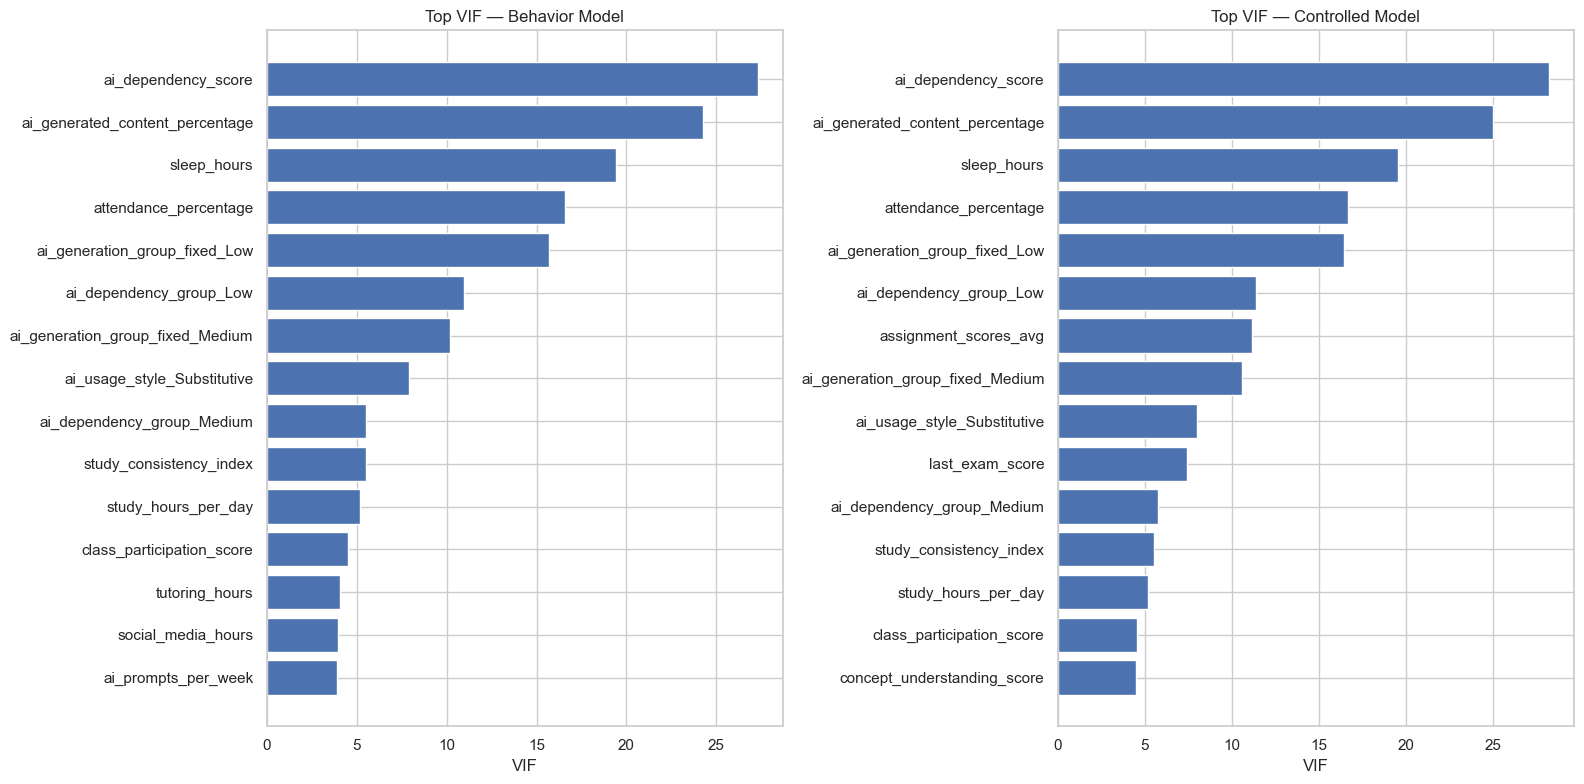

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_b = vif_behavior.head(15).sort_values("VIF", ascending=True)
axes[0].barh(top_b["feature"], top_b["VIF"])
axes[0].set_title("Top VIF — Behavior Model")
axes[0].set_xlabel("VIF")
top_c = vif_control.head(15).sort_values("VIF", ascending=True)
axes[1].barh(top_c["feature"], top_c["VIF"])
axes[1].set_title("Top VIF — Controlled Model")
axes[1].set_xlabel("VIF")
plt.tight_layout()
plt.show()


In [32]:

display(Markdown("### VIF Analysis Summary"))

print("（Behavior Model）：")
print(f"  - Mean VIF: {vif_behavior['VIF'].mean():.2f}")
print(f"  - Max VIF: {vif_behavior['VIF'].max():.2f}")
print(f"  - VIF > 10: {(vif_behavior['VIF'] > 10).sum()}")
print(f"  - VIF > 5: {(vif_behavior['VIF'] > 5).sum()}")

print("\n（Controlled Model）：")
print(f"  - Mean VIF: {vif_control['VIF'].mean():.2f}")
print(f"  - Max VIF: {vif_control['VIF'].max():.2f}")
print(f"  - VIF > 10: {(vif_control['VIF'] > 10).sum()}")
print(f"  - VIF > 5: {(vif_control['VIF'] > 5).sum()}")

display(Markdown("### High VIF Variables (>5)"))
display(Markdown("**Behavior Model:**"))
display(vif_behavior[vif_behavior['VIF'] > 5][['feature', 'VIF']].reset_index(drop=True))
display(Markdown("**Controlled Model:**"))
display(vif_control[vif_control['VIF'] > 5][['feature', 'VIF']].reset_index(drop=True))



### VIF Analysis Summary

（Behavior Model）：
  - Mean VIF: 8.27
  - Max VIF: 27.34
  - VIF > 10: 7
  - VIF > 5: 11

（Controlled Model）：
  - Mean VIF: 8.36
  - Max VIF: 28.25
  - VIF > 10: 8
  - VIF > 5: 13


### High VIF Variables (>5)

**Behavior Model:**

,feature,VIF
0,ai_dependency_score,27.337384
1,ai_generated_content_percentage,24.269550
2,sleep_hours,19.423989
3,attendance_percentage,16.590848
4,ai_generation_group_fixed_Low,15.699069
5,ai_dependency_group_Low,10.986914
6,ai_generation_group_fixed_Medium,10.187468
7,ai_usage_style_Substitutive,7.899274
8,ai_dependency_group_Medium,5.539287
9,study_consistency_index,5.530416


**Controlled Model:**

,feature,VIF
0,ai_dependency_score,28.248355
1,ai_generated_content_percentage,25.010183
2,sleep_hours,19.535338
3,attendance_percentage,16.672489
4,ai_generation_group_fixed_Low,16.471423
5,ai_dependency_group_Low,11.408081
6,assignment_scores_avg,11.182640
7,ai_generation_group_fixed_Medium,10.612345
8,ai_usage_style_Substitutive,8.012910
9,last_exam_score,7.447813


In [33]:
def build_preprocessor(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ]), num_cols, cat_cols

pre_behavior, num_b, cat_b = build_preprocessor(X_behavior)
pre_control, num_c, cat_c = build_preprocessor(X_control)

def get_feature_names(preprocessor, num_cols, cat_cols):
    names = list(num_cols)
    if len(cat_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        names.extend(ohe.get_feature_names_out(cat_cols))
    return names


## 6. Linear models

In [34]:
X_train_b, X_test_b, y_train_reg_b, y_test_reg_b = train_test_split(
    X_behavior, y_reg, test_size=0.2, random_state=SEED
)
pipe_linear_behavior = Pipeline([
    ("preprocess", pre_behavior),
    ("model", LinearRegression())
])
pipe_linear_behavior.fit(X_train_b, y_train_reg_b)
pred_reg_b = pipe_linear_behavior.predict(X_test_b)

metrics_linear_behavior = pd.DataFrame({
    "metric": ["R2_test", "RMSE_test", "MAE_test", "CV_R2_mean"],
    "value": [
        r2_score(y_test_reg_b, pred_reg_b),
        np.sqrt(mean_squared_error(y_test_reg_b, pred_reg_b)),
        mean_absolute_error(y_test_reg_b, pred_reg_b),
        cross_val_score(pipe_linear_behavior, X_behavior, y_reg, cv=5, scoring="r2").mean()
    ]
})
display(Markdown("### Behavior-focused linear regression metrics"))
display(metrics_linear_behavior)


### Behavior-focused linear regression metrics

,metric,value
0,R2_test,0.018615
1,RMSE_test,13.572602
2,MAE_test,11.024527
3,CV_R2_mean,0.002876


In [35]:
X_train_c, X_test_c, y_train_reg_c, y_test_reg_c = train_test_split(
    X_control, y_reg, test_size=0.2, random_state=SEED
)
pipe_linear_control = Pipeline([
    ("preprocess", pre_control),
    ("model", LinearRegression())
])
pipe_linear_control.fit(X_train_c, y_train_reg_c)
pred_reg_c = pipe_linear_control.predict(X_test_c)

metrics_linear_control = pd.DataFrame({
    "metric": ["R2_test", "RMSE_test", "MAE_test", "CV_R2_mean"],
    "value": [
        r2_score(y_test_reg_c, pred_reg_c),
        np.sqrt(mean_squared_error(y_test_reg_c, pred_reg_c)),
        mean_absolute_error(y_test_reg_c, pred_reg_c),
        cross_val_score(pipe_linear_control, X_control, y_reg, cv=5, scoring="r2").mean()
    ]
})
display(Markdown("### Controlled linear regression metrics"))
display(metrics_linear_control)


### Controlled linear regression metrics

,metric,value
0,R2_test,0.869467
1,RMSE_test,4.949989
2,MAE_test,3.919725
3,CV_R2_mean,0.863407


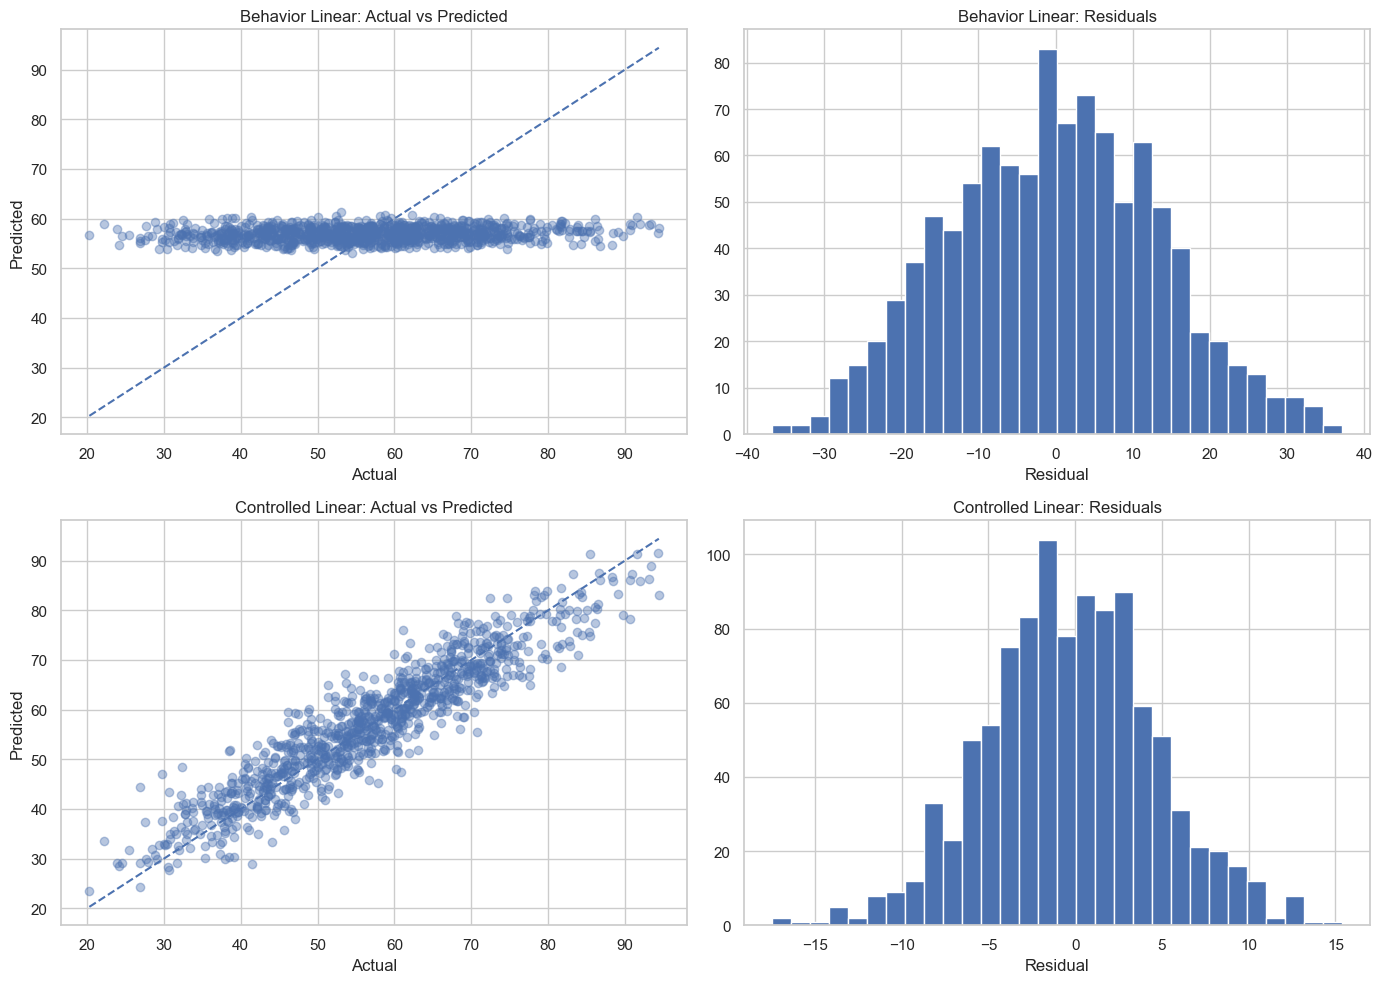

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(y_test_reg_b, pred_reg_b, alpha=0.4)
minv = min(y_test_reg_b.min(), pred_reg_b.min()); maxv = max(y_test_reg_b.max(), pred_reg_b.max())
axes[0, 0].plot([minv, maxv], [minv, maxv], linestyle="--")
axes[0, 0].set_title("Behavior Linear: Actual vs Predicted")
axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted")
axes[0, 1].hist(y_test_reg_b - pred_reg_b, bins=30)
axes[0, 1].set_title("Behavior Linear: Residuals"); axes[0, 1].set_xlabel("Residual")

axes[1, 0].scatter(y_test_reg_c, pred_reg_c, alpha=0.4)
minv2 = min(y_test_reg_c.min(), pred_reg_c.min()); maxv2 = max(y_test_reg_c.max(), pred_reg_c.max())
axes[1, 0].plot([minv2, maxv2], [minv2, maxv2], linestyle="--")
axes[1, 0].set_title("Controlled Linear: Actual vs Predicted")
axes[1, 0].set_xlabel("Actual"); axes[1, 0].set_ylabel("Predicted")
axes[1, 1].hist(y_test_reg_c - pred_reg_c, bins=30)
axes[1, 1].set_title("Controlled Linear: Residuals"); axes[1, 1].set_xlabel("Residual")
plt.tight_layout()
plt.show()


## 7. Logistic models

In [42]:
X_train_b_cls, X_test_b_cls, y_train_cls_b, y_test_cls_b = train_test_split(
    X_behavior, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls
)
pipe_logit_behavior = Pipeline([
    ("preprocess", pre_behavior),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])
pipe_logit_behavior.fit(X_train_b_cls, y_train_cls_b)
pred_cls_b = pipe_logit_behavior.predict(X_test_b_cls)
proba_cls_b = pipe_logit_behavior.predict_proba(X_test_b_cls)[:, 1]

metrics_logit_behavior = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "CV_ROC_AUC_mean"],
    "value": [
        accuracy_score(y_test_cls_b, pred_cls_b),
        precision_score(y_test_cls_b, pred_cls_b, zero_division=0),
        recall_score(y_test_cls_b, pred_cls_b, zero_division=0),
        f1_score(y_test_cls_b, pred_cls_b, zero_division=0),
        roc_auc_score(y_test_cls_b, proba_cls_b),
        average_precision_score(y_test_cls_b, proba_cls_b),
        cross_val_score(pipe_logit_behavior, X_behavior, y_cls, cv=5, scoring="roc_auc").mean()
    ]
})
display(Markdown("### Behavior-focused logistic regression metrics"))
display(metrics_logit_behavior)


### Behavior-focused logistic regression metrics

,metric,value
0,Accuracy,0.496101
1,Precision,0.319109
2,Recall,0.534161
3,F1,0.399535
4,ROC_AUC,0.504711
5,PR_AUC,0.318658
6,CV_ROC_AUC_mean,0.536678


In [43]:
X_train_c_cls, X_test_c_cls, y_train_cls_c, y_test_cls_c = train_test_split(
    X_control, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls
)
pipe_logit_control = Pipeline([
    ("preprocess", pre_control),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])
pipe_logit_control.fit(X_train_c_cls, y_train_cls_c)
pred_cls_c = pipe_logit_control.predict(X_test_c_cls)
proba_cls_c = pipe_logit_control.predict_proba(X_test_c_cls)[:, 1]

metrics_logit_control = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "CV_ROC_AUC_mean"],
    "value": [
        accuracy_score(y_test_cls_c, pred_cls_c),
        precision_score(y_test_cls_c, pred_cls_c, zero_division=0),
        recall_score(y_test_cls_c, pred_cls_c, zero_division=0),
        f1_score(y_test_cls_c, pred_cls_c, zero_division=0),
        roc_auc_score(y_test_cls_c, proba_cls_c),
        average_precision_score(y_test_cls_c, proba_cls_c),
        cross_val_score(pipe_logit_control, X_control, y_cls, cv=5, scoring="roc_auc").mean()
    ]
})
display(Markdown("### Controlled logistic regression metrics"))
display(metrics_logit_control)


### Controlled logistic regression metrics

,metric,value
0,Accuracy,0.884990
1,Precision,0.765625
2,Recall,0.913043
3,F1,0.832861
4,ROC_AUC,0.960068
5,PR_AUC,0.920912
6,CV_ROC_AUC_mean,0.960379


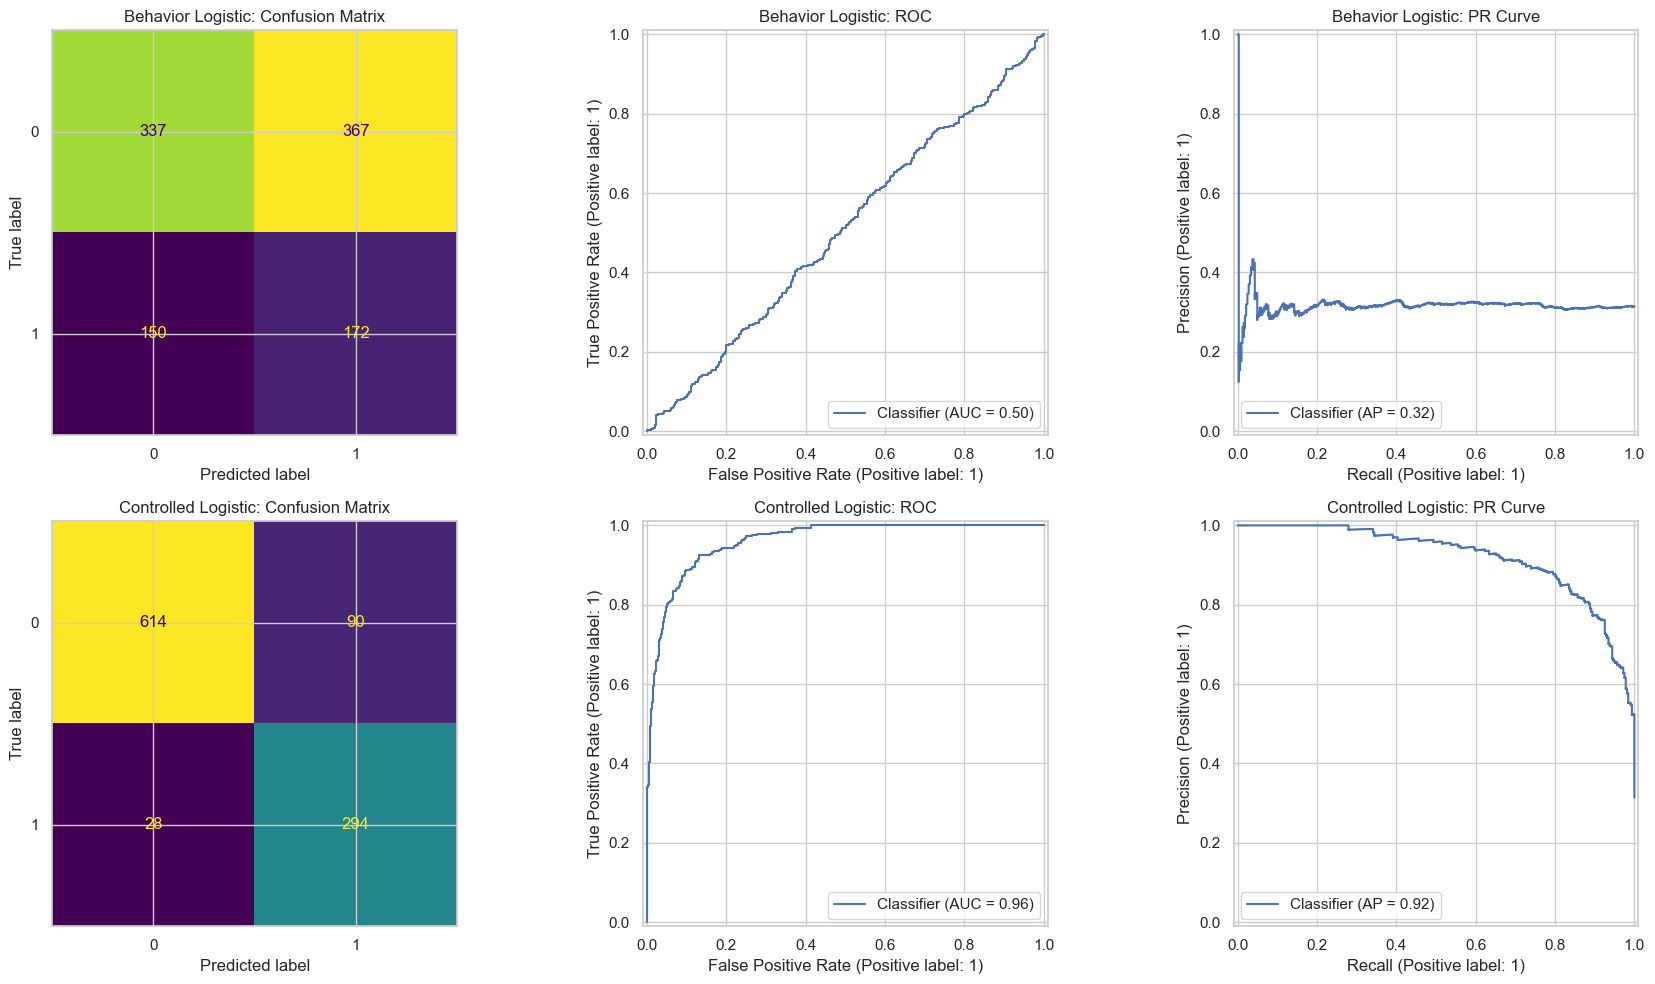

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ConfusionMatrixDisplay.from_predictions(y_test_cls_b, pred_cls_b, ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Behavior Logistic: Confusion Matrix")
RocCurveDisplay.from_predictions(y_test_cls_b, proba_cls_b, ax=axes[0, 1])
axes[0, 1].set_title("Behavior Logistic: ROC")
PrecisionRecallDisplay.from_predictions(y_test_cls_b, proba_cls_b, ax=axes[0, 2])
axes[0, 2].set_title("Behavior Logistic: PR Curve")

ConfusionMatrixDisplay.from_predictions(y_test_cls_c, pred_cls_c, ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Controlled Logistic: Confusion Matrix")
RocCurveDisplay.from_predictions(y_test_cls_c, proba_cls_c, ax=axes[1, 1])
axes[1, 1].set_title("Controlled Logistic: ROC")
PrecisionRecallDisplay.from_predictions(y_test_cls_c, proba_cls_c, ax=axes[1, 2])
axes[1, 2].set_title("Controlled Logistic: PR Curve")
plt.tight_layout()
plt.show()


## 8. Lasso & L1 logistic / Lasso 与 L1 逻辑回归

In [46]:
pipe_lasso = Pipeline([
    ("preprocess", pre_control),
    ("model", LassoCV(cv=5, random_state=SEED, max_iter=10000))
])
pipe_lasso.fit(X_train_c, y_train_reg_c)
pred_lasso = pipe_lasso.predict(X_test_c)

metrics_lasso = pd.DataFrame({
    "metric": ["R2_test", "RMSE_test", "MAE_test", "CV_R2_mean", "alpha_selected"],
    "value": [
        r2_score(y_test_reg_c, pred_lasso),
        np.sqrt(mean_squared_error(y_test_reg_c, pred_lasso)),
        mean_absolute_error(y_test_reg_c, pred_lasso),
        cross_val_score(pipe_lasso, X_control, y_reg, cv=5, scoring="r2").mean(),
        pipe_lasso.named_steps["model"].alpha_
    ]
})
display(Markdown("### Lasso regression metrics"))
display(metrics_lasso)


### Lasso regression metrics

,metric,value
0,R2_test,0.870031
1,RMSE_test,4.939276
2,MAE_test,3.910003
3,CV_R2_mean,0.863935
4,alpha_selected,0.036808


### Lasso selected features

,feature,coef,abs_coef
11,last_exam_score,9.140559,9.140559
12,assignment_scores_avg,5.978299,5.978299
13,concept_understanding_score,5.745015,5.745015
0,ai_generated_content_percentage,-1.585196,1.585196
6,attendance_percentage,-0.129267,0.129267
2,ai_prompts_per_week,-0.113881,0.113881
4,study_hours_per_day,0.093057,0.093057
10,tutoring_hours,-0.068006,0.068006
5,study_consistency_index,-0.044926,0.044926
8,sleep_hours,0.011895,0.011895


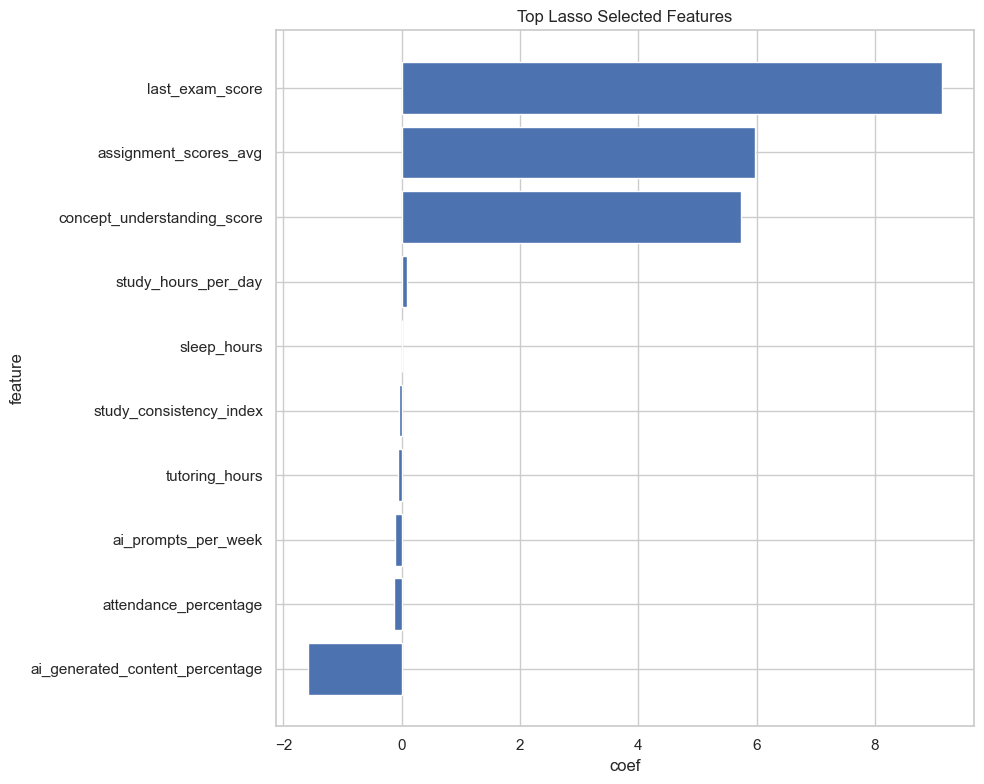

In [ ]:
pipe_lasso.fit(X_control, y_reg)
features_lasso = get_feature_names(pipe_lasso.named_steps["preprocess"], num_c, cat_c)
coef_lasso = pipe_lasso.named_steps["model"].coef_
lasso_df = pd.DataFrame({"feature": features_lasso, "coef": coef_lasso})
lasso_selected = lasso_df[lasso_df["coef"] != 0].copy()
lasso_selected["abs_coef"] = lasso_selected["coef"].abs()
lasso_selected = lasso_selected.sort_values("abs_coef", ascending=False)

display(Markdown("### Lasso selected features"))
display(lasso_selected.head(25))

plt.figure(figsize=(10, 8))
plot_df = lasso_selected.head(15).sort_values("coef")
plt.barh(plot_df["feature"], plot_df["coef"])
plt.title("Top Lasso Selected Features")
plt.xlabel("coef"); plt.ylabel("feature")
plt.tight_layout()
plt.show()


In [47]:
pipe_logit_l1 = Pipeline([
    ("preprocess", pre_control),
    ("model", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=3000, class_weight="balanced"
    ))
])
pipe_logit_l1.fit(X_train_c_cls, y_train_cls_c)
pred_l1 = pipe_logit_l1.predict(X_test_c_cls)
proba_l1 = pipe_logit_l1.predict_proba(X_test_c_cls)[:, 1]

metrics_logit_l1 = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "CV_ROC_AUC_mean"],
    "value": [
        accuracy_score(y_test_cls_c, pred_l1),
        precision_score(y_test_cls_c, pred_l1, zero_division=0),
        recall_score(y_test_cls_c, pred_l1, zero_division=0),
        f1_score(y_test_cls_c, pred_l1, zero_division=0),
        roc_auc_score(y_test_cls_c, proba_l1),
        average_precision_score(y_test_cls_c, proba_l1),
        cross_val_score(pipe_logit_l1, X_control, y_cls, cv=5, scoring="roc_auc").mean()
    ]
})
display(Markdown("### L1-regularized logistic regression metrics"))
display(metrics_logit_l1)


### L1-regularized logistic regression metrics

,metric,value
0,Accuracy,0.885965
1,Precision,0.766234
2,Recall,0.916149
3,F1,0.834512
4,ROC_AUC,0.960320
5,PR_AUC,0.921472
6,CV_ROC_AUC_mean,0.960540


In [48]:
def append_metrics(model_name, metric_df):
    temp = metric_df.copy()
    temp["model"] = model_name
    return temp[["model", "metric", "value"]]

final_metrics = pd.concat([
    append_metrics("Behavior_Linear", metrics_linear_behavior),
    append_metrics("Controlled_Linear", metrics_linear_control),
    append_metrics("Behavior_Logistic", metrics_logit_behavior),
    append_metrics("Controlled_Logistic", metrics_logit_control),
    append_metrics("Lasso_Regression", metrics_lasso),
    append_metrics("L1_Logistic", metrics_logit_l1)
], ignore_index=True)

display(Markdown("### Final model comparison table"))
display(final_metrics)
display(Markdown("### Pivoted model comparison"))
display(final_metrics.pivot_table(index="model", columns="metric", values="value", aggfunc="first").round(4))


### Final model comparison table

,model,metric,value
0,Behavior_Linear,R2_test,0.018615
1,Behavior_Linear,RMSE_test,13.572602
2,Behavior_Linear,MAE_test,11.024527
3,Behavior_Linear,CV_R2_mean,0.002876
4,Controlled_Linear,R2_test,0.869467
5,Controlled_Linear,RMSE_test,4.949989
6,Controlled_Linear,MAE_test,3.919725
7,Controlled_Linear,CV_R2_mean,0.863407
8,Behavior_Logistic,Accuracy,0.496101
9,Behavior_Logistic,Precision,0.319109


### Pivoted model comparison

metric,Accuracy,CV_R2_mean,CV_ROC_AUC_mean,F1,MAE_test,PR_AUC,Precision,R2_test,RMSE_test,ROC_AUC,Recall,alpha_selected
model,,,,,,,,,,,,
Behavior_Linear,NaN,0.0029,NaN,NaN,11.0245,NaN,NaN,0.0186,13.5726,NaN,NaN,NaN
Behavior_Logistic,0.4961,NaN,0.5367,0.3995,NaN,0.3187,0.3191,NaN,NaN,0.5047,0.5342,NaN
Controlled_Linear,NaN,0.8634,NaN,NaN,3.9197,NaN,NaN,0.8695,4.9500,NaN,NaN,NaN
Controlled_Logistic,0.8850,NaN,0.9604,0.8329,NaN,0.9209,0.7656,NaN,NaN,0.9601,0.9130,NaN
L1_Logistic,0.8860,NaN,0.9605,0.8345,NaN,0.9215,0.7662,NaN,NaN,0.9603,0.9161,NaN
Lasso_Regression,NaN,0.8639,NaN,NaN,3.9100,NaN,NaN,0.8700,4.9393,NaN,NaN,0.0368
